# Chapter 07 딥러닝을 시작합니다
## 07-2 심층 신경망
### 2개의 층

In [ ]:
from tensorflow import keras
(train_input, train_target), (test_input, test_target) = keras.datasets.fashion_mnist.load_data()

In [ ]:
from sklearn.model_selection import train_test_split
train_scaled = train_input / 255.0
train_scaled = train_scaled.reshape(-1, 28*28)
train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42
)

* 이제 인공 신경망 모델에 층을 2개 추가해 보겠음. 여기서 만들 모델의 대략적인 구조는 다음 그림과 같음.

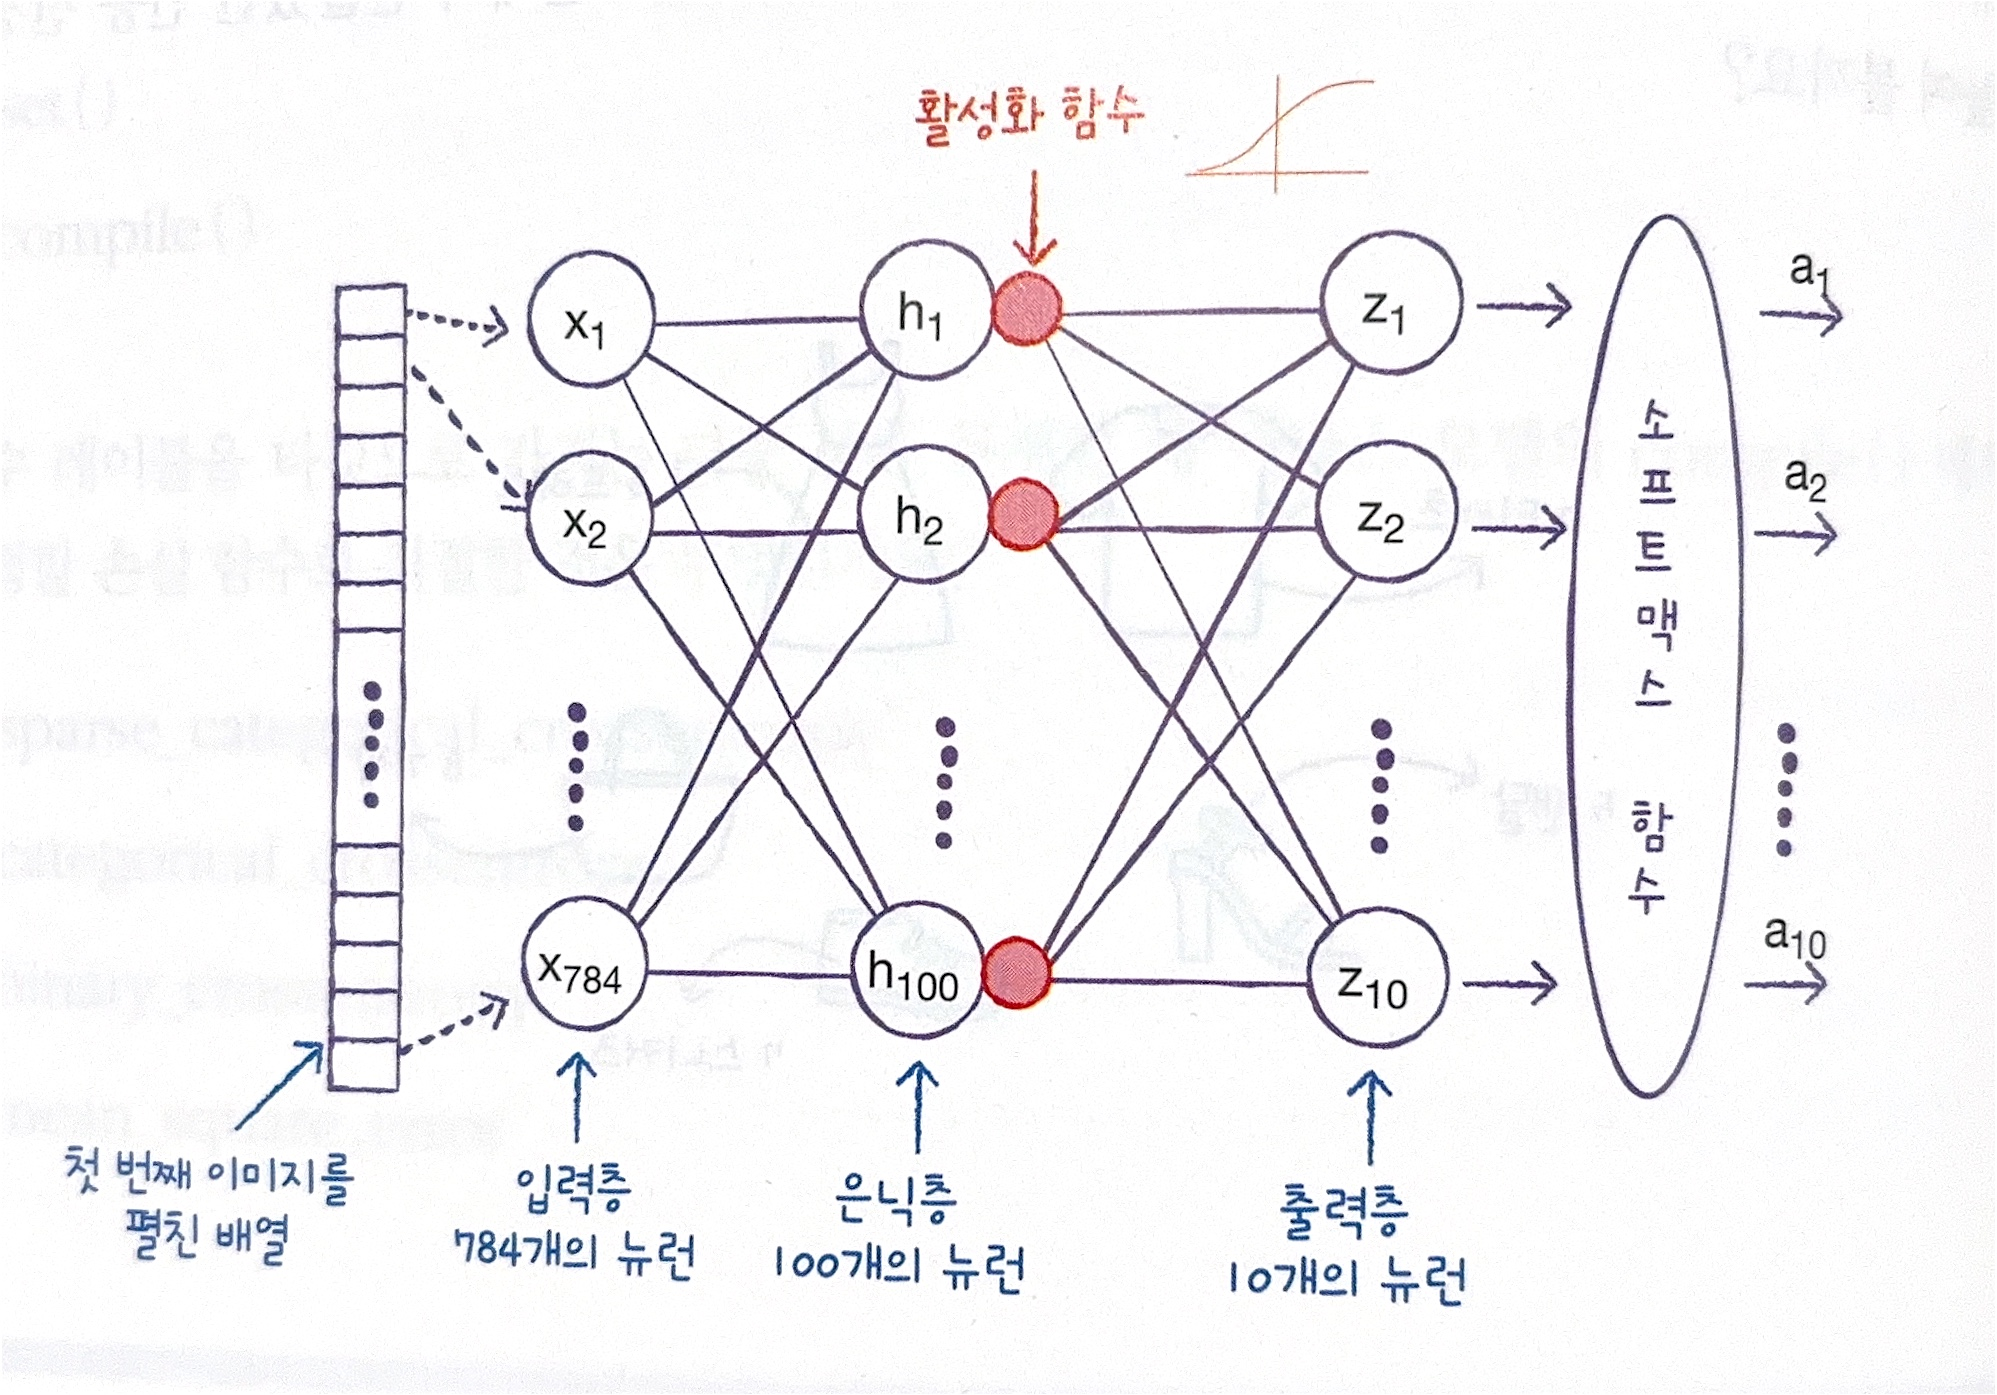


* 1절을 만든 신경망 모델과 다른 점은 입력층과 출력층 사이에 밀집층이 추가된 것입니다. 이렇게 입력층과 출력층 사이에 있는 모든 층을 **은닉층hidden layer**이라고 부름.
* 은닉층에는 주황색 원으로 활성화 함수가 표시되어 있음. 활성화 함수는 신경망 층의 선형 방정식의 계산 값에 적용하는 함수. 이전 절에서 출력층에 적용했던 소프트맥스 함수도 활성화 함수. 출력층에 적용하는 활성화 함수는 종류가 제한되어 있음. 이진 분류일 경우 시그모이드 함수를 사용하고 다중 분류일 경우 소프트맥스 함수를 사용. 이에 비해 은닉층의 활성화 함수는 비교적 자유로움. 대표적으로 시그모이드 함수와 잠시 후에 볼 렐루ReLU 함수 등을 사용.

> 회귀를 위한 신경망의 출력층에서는 어떤 활성화 함수를 사용하나요?
> * 분류 문제는 클래스에 대한 확률을 출력하기 위해 활성화 함수를 사용. 회귀의 출력은 임의의 어떤 숫자이므로 활성화 함수를 적용할 필요가 없음. 즉 출력층의 선형 방정식의 계산을 그대로 출력. 이렇게 하려면 Dense 층의 activation 매개변수에 아무런 값을 지정하지 않음.
* 그런데 은닉층에 왜 활성화 함수를 적용할까? -> 은닉층에서 선형적인 산술 계산만 수행한다면 수행 역할이 없는 셈. 선형 계산을 적당하게 비선형적으로 비틀어 주어야 함. 그래야 다음 층의 계산과 단순히 합쳐지지 않고 나름의 역할을 할 수 있음.

> 다른 책에서 보니 인공 신경망 그림에 활성화 함수가 없던데요?
> * 인공 신경망을 그림으로 나타낼 때 활성화 함수를 생략하는 경우가 많은데 이는 절편과 마찬가지로 번거로움을 피하기 위해서 활성화 함수를 별개의 층으로 생각하지 않고 층에 포함되어 있다고 간주하기 때문. 그림에서 보이지는 않지만 모든 신경망의 은닉층에는 항상 활성화 함수가 있음!

In [ ]:
dense1 = keras.layers.Dense(100, activation='sigmoid', input_shape=(784,))
dense2 = keras.layers.Dense(10, activation='softmax')

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


* 여기에서 한 가지 제약 사항이 있다면 적어도 출력층의 뉴런보다는 많게 만들어야 함. 클래스 10개에 대한 확률을 예측해야 하는데 이전 은닉층의 뉴런이 10개보다 적다면 부족한 정보가 전달될 것.

### 심층 신경망 만들기
* 이제 앞에서 만든 dense1과 dense2 객체를 Sequential 클래스에 추가하여 심층 신경망deep neural network, DNN을 만들어 보겠음.

In [ ]:
model = keras.Sequential([dense1, dense2])

* Sequential 클래스의 객체를 만들 때 여러 개의 층을 추가하려면 이와 같이 dense1과 dense2를 리스트로 만들어 전달. 여기서 주의할 것은 출력층을 가장 마지막에 두어야 한다는 것.
* 인공 신경망의 강력한 성능은 바로 이렇게 층을 추가하여 입력 데이터에 대해 연속적인 학습을 진행하는 능력에서 나옴.
* 케라스는 모델의 summary() 메서드를 호출하면 층에 대한 유용한 정보를 얻을 수 있음.

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

* 출력 크기를 보면 (None, 100). 첫 번째 차원은 샘플의 개수. 샘플 개수가 아직 정의되어 있지 않기 때문에 None. 왜? 케라스 모델의 fit() 메서드에 훈련 데이터를 주입하면 이 데이터를 한 번에 모두 사용하지 않고 잘게 나누어 여러 번에 걸쳐 경사 하강법 단계를 수행. -> 미니배치 경사 하강법을 사용.
* 케라스의 기본 미니배치 크기는 32개. 이 값은 fit() 메서드에서 batch_size 매개변수로 바꿀 수 있음. 따라서 샘플 개수를 고정하지 않고 어떤 배치 크기에도 유연하게 대응할 수 있도록 None으로 설정. 이렇게 신경망 층에 입력되거나 출력되는 배열의 첫 번째 차원을 배치 차원이라고 부름.
* 두 번째 100은 쉬움. 은닉층의 뉴런 개수를 100개로 두었으니 100개의 출력. 즉 샘플마다 784개의 픽셀값이 은닉층을 통과하면서 100개의 특성으로 압축되었음.
* 마지막으로 모델 파라미터 개수가 출력. 이 층은 Dense 층이므로 입력 픽셀 784개와 100개의 모든 조합에 대한 가중치가 있음. 그리고 뉴런마다 1개의 절편이 있음.
* 두 번째 층의 출력 크기는 (None, 10). 배치 차원은 동일하게 None이고 출력 뉴런 개수가 10개이기 때문. 이 층의 모델 파라미터 개수는 몇 개? -> 100개의 은닉층 뉴런과 10개의 출력층 뉴런이 모두 연결되고 출력층의 뉴런마다 하나의 절편이 있기 때문에 총 1,010개의 모델 파라미터가 있음.
* summary() 메서드의 마지막에는 총 모델 파라미터 개수와 훈련되는 파라미터 개수가 동일하게 79,510개로 나옴. 은닉층과 출력층의 파라미터 개수를 합친 값. 그 아래 훈련되지 않는 파라미터(Non-trainable parrams)는 0으로 나옴. 간혹 경사 하강법으로 훈련되지 않는 파라미터를 가진 층이 있음. 이런 층의 파라미터 개수가 여기에 나타남.

### 층을 추가하는 다른 방법
* 앞에서는 Dense 클래스의 객체 dense1, dense2를 만들어 Sequential 클래스에 전달했음. 이 두 객체를 따로 저장하여 쓸 일이 없기 때문에 다음처럼 Sequential 클래스의 생성자 안에서 바로 Dense 클래스의 객체를 만드는 경우가 많음.

In [ ]:
model = keras.Sequential([
    keras.layers.Dense(100, activation='sigmoid', input_shape=(784,),
                       name='hidden'),
    keras.layers.Dense(10, activation='softmax', name='output')
], name='fashion_mnist_model')

* 이렇게 작업하면 추가되는 층을 한눈에 쉽게 알아보는 장점.
* 모델의 이름과 달리 층의 이름은 반드시 영문이어야 함.

In [ ]:
model.summary()

Model: "fashion_mnist_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden (Dense)                  │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

* 2개의 Dense 층이 이전과 동일하게 추가되었고 파라미터 개수도 같음. 바뀐 것은 모델 이름과 층 이름. 여러 모델과 많은 층을 사용할 때 name 매개변수를 사용하면 구분하기 쉬움.
이 방법이 편리하지만 아주 많은 층을 추가하려면 Sequential 클래스 생성자가 매우 길어짐. 또 조건에 따라 층을 추가할 수도 없음. Sequential 클래스에서 층을 추가할 때 가장 널리 사용하는 방법은 모델의 add() 메서드.

In [ ]:
model = keras.Sequential()
model.add(keras.layers.Dense(100, activation='sigmoid', input_shape=(784,)))
model.add(keras.layers.Dense(10, activation='softmax'))

In [ ]:
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(train_scaled, train_target, epochs=5)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8068 - loss: 0.5687
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8516 - loss: 0.4129
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8649 - loss: 0.3770
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8720 - loss: 0.3535
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8779 - loss: 0.3361


* 훈련 세트에 대한 성능을 보면 추가된 층이 성능을 향상시켰다는 것을 잘 알 수 있음. 인공 신경망에 몇 개의 층을 추가하더라도 compile() 메서드와 fit() 메서드의 사용법은 동일. 이것이 케라스 API의 장점.

### 렐루 함수
* 초창기 인공 신경망의 은닉층에 많이 사용된 활성화 함수는 시그모이드 함수. 하지만 이 함수에는 단점이 있음. 이 함수의 오른쪽과 왼쪽 끝으로 갈수록 그래프가 누워있기 때문에 올바른 출력을 만드는데 신속하게 대응하지 못함.
* 특히 층이 많은 심층 신경망일수록 그 효과가 누적되어 학습을 더 어렵게 만듦. 이를 개선하기 위해 다른 종류의 활성화 함수가 제안되었음. -> 렐루ReLU 함수
* 렐루 함수는 아주 간단. 입력이 양수일 경우 마치 활성화 함수가 없는 것처럼 그냥 입력을 통과시키고 음수일 경우에는 0으로 만듦.
* 렐루 함수는 max(0, z)와 같이 쓸 수 있음. 이 함수는 z가 0보다 크면 z를 출력하고 z가 0보다 작으면 0을 출력. 렐루 함수는 특히 이미지 처리에서 좋은 성능을 낸다고 알려져 있음. 은닉층의 활성화 함수에 시그모이드 함수 대신 렐루 함수를 적용하기 전에 케라스에서 제공하는 편리한 층 하나를 더 살펴보겠음.
* 패션 MNIST 데이터는 28 $\times$ 28 크기이기 때문에 인공 신경망에 주입하기 위해 넘파이 배열의 ```reshape()``` 메서드를 사용해 1차원으로 펼쳤음. 직접 이렇게 1차원으로 펼쳐도 좋지만 케라스에서는 이를 위한 Flatten 층을 제공.
* 사실 Flatten 클래스는 배치 차원을 제외하고 나머지 입력 차원을 모두 일렬로 펼치는 역할만 함. 입력에 곱해지는 가중치나 절편이 없음. -> 인공 신경망의 성능을 위해 기여하는 바는 없음. 하지만 Flatten 클래스를 층처럼 입력층과 은닉층 사이에 추가하기 때문에 이를 층이라 부름.

In [ ]:
model = keras.Sequential()
model.add(keras.layers.Flatten(input_shape=(28, 28)))
model.add(keras.layers.Dense(100, activation='relu'))
model.add(keras.layers.Dense(10, activation='softmax'))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


* 하지만 이 신경망을 깊이가 3인 신경망이라고 부르지는 않음. Flatten 클래스는 학습하는 층이 아니니까.

In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

* 첫 번째 등장하는 Flatten 클래스에 포함된 모델 파라미터는 0개. 케라스의 Flatten 층을 신경망 모델에 추가하면 입력값의 차원을 짐작할 수 있는 것이 또 하나의 장점. 앞의 출력에서 784개의 입력이 첫 번째 은닉층에 전달된다는 것을 알 수 있음. 이는 이전에 만들었던 모델에서는 쉽게 눈치채기 어려웠음. 입력 데이터에 대한 전처리 과정을 가능한 모델에 포함시키는 것이 케라스 API의 철학 중 하나.

In [ ]:
(train_input, train_target), (test_input, test_target) = keras.datasets.fashion_mnist.load_data()
train_scaled = train_input / 255.0
train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42
)

In [ ]:
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(train_scaled, train_target, epochs=5)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8117 - loss: 0.5333
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8577 - loss: 0.3933
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8709 - loss: 0.3561
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8798 - loss: 0.3336
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8852 - loss: 0.3208


* 시그모이드 함수를 사용했을 때와 비교하면 성능이 조금 향상되었음. 크지 않지만 렐루 함수의 효과를 보았음.

In [ ]:
model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8610 - loss: 0.4073


[0.407268762588501, 0.8610000014305115]

### 옵티마이저
* 추가할 은닉층의 개수는 모델이 학습하는 것이 아니라 우리가 지정해 주어야 할 하이퍼파라미터. 그럼 은닉층의 뉴런 개수도 하이퍼파라미터? -> 맞음. 또 활성화 함수도 선택해야 할 하이퍼파라미터 중 하나. 심지어 층의 종류도 하이퍼파라미터.
* 케라스는 기본적으로 미니배치 경사 하강법을 사용하며 미니배치 개수는 32개. ```fit()``` 메서드의 batch_size 매개변수에서 이를 조정할 수 있으며 역시 하이퍼파라미터. 또한 ```fit()``` 메서드의 epochs 매개변수도 하이퍼파라미터! 반복 횟수에 따라 다른 모델이 만들어짐.
* 마지막으로 ```compile()``` 메서드에서는 케라스의 기본 경사 하강법 알고리즘인 RMSprop을 사용했음. 케라스는 다양한 종류의 경사 하강법 알고리즘을 제공. 이들을 **옵티마이저optimizer**라고 부름.
* 또한 RMSprop의 학습률 또한 조정할 하이퍼파라미터 중 하나.
* 가장 기본적인 옵티마이저는 확률적 경사 하강법인 SGD. 이름이 SGD이지만 1개의 샘플을 뽑아서 훈련하지 않고 앞서 언급한 것처럼 기본적으로 미니배치를 사용.


```
model.compile(optimizer='sgd', loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
```

* 'sgd' 문자열은 이 클래스의 기본 설정 매개변수로 생성한 객체와 동일. 즉 다음 코드는 위의 코드와 정확히 동일.


```
sgd = keras.optimizers.SGD()
model.compile(optimizer=sgd, loss='sparse_categorical_crossentropy',
              metrics=['accuracy])
```

> sgd와 'sgd'의 차이가 무엇인가요?
> * 원래 sgd = keras.optimizers.SGD()처럼 SGD 클래스 객체를 만들어 사용해야 함. 번거로움을 피하고자 'sgd'라 지정하면 자동으로 SGD 클래스 객체를 만들어 줌.

* 만약 SGD 클래스의 학습률 기본값이 0.01일 때 이를 바꾸고 싶다면 다음과 같이 원하는 학습률을 learning_rate 매개변수에 지정하여 사용.


```
sgd = keras.optimizers.SGD(learning_rate=0.1)
```


* 기본 경사 하강법 옵티마이저는 모두 SGD 클래스에서 제공. SGD 클래스의 momentum 매개변수의 기본값은 0. 이를 0보다 큰 값으로 지정ㅇ하면 마치 이전의 그레이디언트를 가속도처럼 사용하는 **모멘텀 최적화momentum optimization**를 사용. 보통 momentum 매개변수는 0.9 이상을 지정.
* 다음처럼 SGD 클래스의 nesterov 매개변수를 기본값 False에서 True로 바꾸면 **네스테로프 모멘텀 최적화nesterov momentum optimization(또는 네스테로프 가속 경사)**를 사용.


```
sgd = keras.optimizers.SGD(momentum=0.9, nesterov=True)
```

* 네스테로프 모멘텀은 모멘텀 최적화를 2번 반복하여 구현. 대부분의 경우 네스테로프 모멘텀 최적화가 기본 확률적 경사 하강법보다 더 나은 성능을 제공.
모델이 최적점에 가까이 갈수록 학습률을 낮출 수 있음. 이렇게 하면 안정적으로 최적점에 수렴할 가능성이 높음. 이런 학습률을 **적응적 학습률adaptive learning rate**이라고 함. 이런 방식들은 학습률 매개변수를 튜닝하는 수고를 덜 수 있는 것이 장점.
* 적응적 학습률을 사용하는 대표적인 옵티마이저는 Adagrad와 RMSprop. 각각 ```compile()``` 메서드의 optimizer 매개변수에 'adagrad'와 'rmsprop'으로 지정할 수 있음. optimizer 매개변수의 기본값이 바로 'rmsprop'. 이 두 옵티마이저의 매개변수를 바꾸고 싶다면 SGD와 같이 Adagrad와 RMSprop 클래스 객체를 만들어 사용하면 됨.
```
adagrad = keras.optimizers.Adagrad()
model.compile(optimizer=adagrad, loss='sparse_categorical_crossentropy', metrics=['accuracy])
```
* RMSprop도 마찬가지.
```
rmsprop = keras.optimizers.RMSprop()
model.compile(optimizer=rmsprop, loss='sparse_categorical_crossentropy', metrics=['accuracy])
```
* 모멘텀 최적화와 RMSprop의 장점을 접목한 것이 Adam. Adam은 RMSprop과 함께 맨처음 시도해 볼 수 있는 좋은 알고리즘. Adam 클래스도 keras.optimizers 패키지 아래에 있음. 적응적 학습률을 사용하는 이 3개의 클래스는 learning_rate 매개변수의 기본값으로 모두 0.001을 사용.

> 이런 고급 옵티마이저들의 구체적인 작동 방식은 어떻게 되나요?
> * 다양한 옵티마이저들의 이론과 개념을 잘 설명한 『핸즈온 머신러닝 2판』(한빛미디어, 2020)의 11장을 참고할 것.

In [16]:
model = keras.Sequential()
model.add(keras.layers.Flatten(input_shape=(28,28)))
model.add(keras.layers.Dense(100, activation='relu'))
model.add(keras.layers.Dense(10, activation='softmax'))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


* ```compile()``` 메서드의 optimizer를 'adam'으로 설정하고 5번의 에포크 동안 훈련.

In [17]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(train_scaled, train_target, epochs=5)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8141 - loss: 0.5313
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8576 - loss: 0.3949
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8723 - loss: 0.3531
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8803 - loss: 0.3278
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8859 - loss: 0.3077


* 이 출력 결과를 보면 기본 RMSprop을 사용했을 때와 거의 같은 성능을 보여 줌.

In [18]:
model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8773 - loss: 0.3434


[0.3433842658996582, 0.8772500157356262]